# Laboratorio 4: difusión de calor en una placa con el método de diferencias finitas

**Andrés Felipe Serrano Barrios**

Física Computacional I (0302151), grupo 001

Instituto de Física, Universidad de Antioquia

Semestre 2026-2, profesor Andrés Felipe Rivera Romero

---

Placa rectangular de aluminio de lados $a=20$ mm y $b=10$ mm, con difusividad térmica
$D\approx 84\ \text{mm}^2/\text{s}$. Las caras planas están aisladas, así que el problema es
bidimensional y la temperatura obedece

$$\frac{\partial u}{\partial t}=D\left(\frac{\partial^2u}{\partial x^2}
+\frac{\partial^2u}{\partial y^2}\right).$$

Las fronteras se mantienen a $u=0$ en los lados $x=0$, $x=a$ y $y=0$, y a
$u(x,b)=f(x)=100\,\sin(3\pi x/a)$ grados Celsius (°C) en el borde superior. El arreglo guarda
$u_{i,j}=u(x_i,y_j)$, primer índice sobre $x$.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from matplotlib import animation

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

---

# 1. Solución estática por diferencias finitas

En el estado estacionario $\partial u/\partial t=0$ y la ecuación de difusión se reduce a
$\nabla^2u=0$. Sumando los desarrollos de Taylor a izquierda y derecha de un nodo, las derivadas
segundas quedan $(u_{i+1,j}-2u_{i,j}+u_{i-1,j})/\Delta x^2$ y su análoga en $y$; con
$\Delta x=\Delta y$ el paso se cancela y la ecuación se vuelve una **propiedad de promedio**:

$$\boxed{\;u_{i,j}=\tfrac14\left[u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}\right]\;}$$

Los $(n_x-1)(n_y-1)$ nodos interiores quedan acoplados, así que en vez de invertir la matriz se
**relaja** con Jacobi, repitiendo el promedio sobre una copia de la malla hasta que el mayor cambio
de un barrido baje de $\varepsilon$.

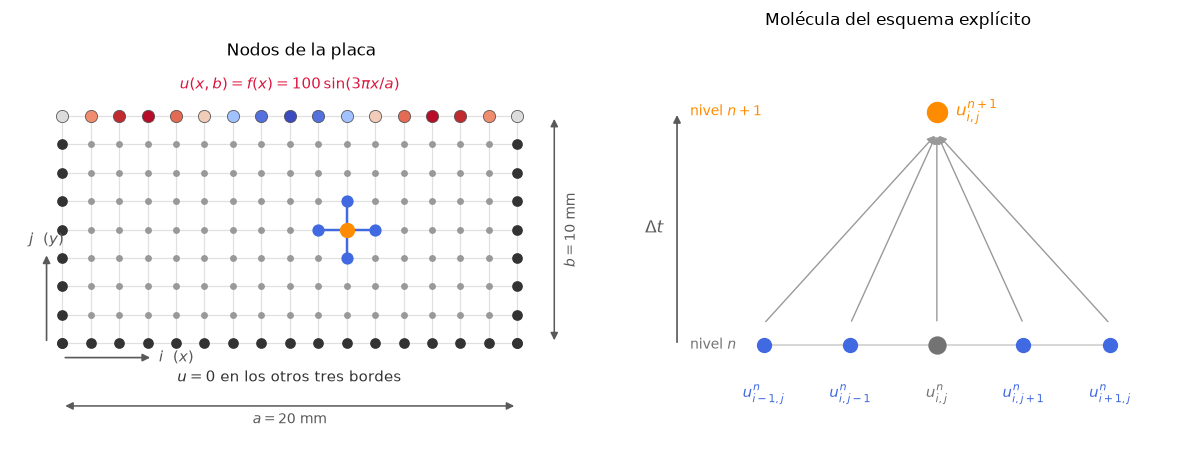

In [2]:
a = 20.0
b = 10.0
D = 84.0
dx = dy = 0.1

nx = int(a/dx)
ny = int(b/dy)
x = np.linspace(0.0, a, nx+1)
y = np.linspace(0.0, b, ny+1)


def malla_inicial():
    """Fronteras de Dirichlet, interior en cero."""
    malla = np.zeros((nx+1, ny+1))
    malla[:, ny] = 100.0*np.sin(3.0*np.pi*x/a)
    return malla


def barrido_jacobi(u, u_viejo):
    """Un barrido de Jacobi, vectorizado."""
    u[1:-1, 1:-1] = 0.25*(u_viejo[2:, 1:-1] + u_viejo[:-2, 1:-1]
                          + u_viejo[1:-1, 2:] + u_viejo[1:-1, :-2])
    return np.abs(u[1:-1, 1:-1] - u_viejo[1:-1, 1:-1]).max()


def relajacion_jacobi(epsilon, max_barridos=100000):
    """Relaja hasta bajar de epsilon."""
    u = malla_inicial()
    mayor = 0.0
    for barridos in range(1, max_barridos+1):
        u_viejo = u.copy()
        mayor = barrido_jacobi(u, u_viejo)
        if mayor < epsilon:
            return u, barridos, mayor
    return u, max_barridos, mayor


reloj = time.perf_counter()
u_estatica, barridos, ultimo_cambio = relajacion_jacobi(1e-6)

print(f"malla de {nx+1} x {ny+1} nodos, paso {dx} mm")
print(f"{barridos} barridos en {time.perf_counter() - reloj:.2f} s")
print(f"ultimo cambio: {ultimo_cambio:.2e} grados C")
print(f"u(a/2, b/2) = {u_estatica[nx//2, ny//2]:.4f} grados C")

malla de 201 x 101 nodos, paso 0.1 mm
12047 barridos en 0.83 s
ultimo cambio: 1.00e-06 grados C
u(a/2, b/2) = -9.3964 grados C


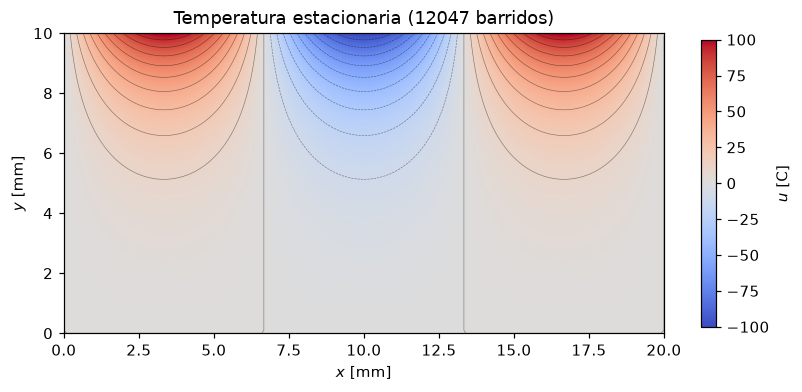

In [3]:
def mapa_temperatura(ax, campo, titulo, niveles=None):
    """Mapa de temperatura, a escala."""
    if niveles is None:
        niveles = np.linspace(-90.0, 90.0, 19)
    imagen = ax.imshow(campo.T, origin="lower", extent=[0.0, a, 0.0, b],
                       cmap="coolwarm", vmin=-100.0, vmax=100.0, aspect="equal")
    ax.contour(x, y, campo.T, levels=niveles, colors="k", linewidths=0.4, alpha=0.45)
    ax.set_xlabel("$x$ [mm]")
    ax.set_ylabel("$y$ [mm]")
    ax.set_title(titulo)
    return imagen


fig, ax = plt.subplots(figsize=(7.6, 3.6))
imagen = mapa_temperatura(ax, u_estatica, f"Temperatura estacionaria ({barridos} barridos)")
fig.colorbar(imagen, ax=ax, label="$u$ [C]", shrink=0.85)
fig.tight_layout()
plt.show()

Las tres medias ondas del borde superior entran a la placa y se apagan antes de llegar al borde
frío de abajo: a media altura la temperatura no pasa de $10$ C en valor absoluto. Los lóbulos
quedan separados por las rectas $x=a/3$ y $x=2a/3$, donde el dato del borde se anula y el campo se
queda en cero a toda altura.

---

# 2. Comparación con la solución analítica

Separando variables, $u(x,y)=X(x)Y(y)$, la ecuación de Laplace parte en dos EDO con la misma
constante de separación:

$$\frac{X''}{X}=-\frac{Y''}{Y}=-k^2\quad\Rightarrow\quad X''+k^2X=0,\qquad Y''-k^2Y=0.$$

Las fronteras homogéneas $u(0,y)=u(a,y)=0$ piden $X(0)=X(a)=0$: $X$ oscila y solo sobreviven
$k=n\pi/a$, con $X_n(x)=\sin(n\pi x/a)$. Con $Y''-k^2Y=0$ la solución es
$A\,\mathrm{senh}(ky)+B\,\mathrm{cosh}(ky)$, y $u(x,0)=0$ pide $Y(0)=0$, así que $B=0$ y
$Y_n(y)=\mathrm{senh}(n\pi y/a)$. Superponiendo los modos, que ya cumplen tres de las cuatro
fronteras,

$$u(x,y)=\sum_{n=1}^{\infty}c_n\sin\!\left(\frac{n\pi x}{a}\right)\mathrm{senh}\!\left(\frac{n\pi y}{a}\right),$$

queda por imponer la cuarta, $u(x,b)=f(x)$. Los $\sin(n\pi x/a)$ son ortogonales en $[0,a]$, así
que multiplicando por $\sin(m\pi x/a)$ e integrando se despeja cada coeficiente:

$$c_n\,\mathrm{senh}\!\left(\frac{n\pi b}{a}\right)=\frac{2}{a}\int_0^a f(x)\sin\!\left(\frac{n\pi x}{a}\right)dx.$$

El dato del borde ya es uno de esos modos, $f(x)=100\sin(3\pi x/a)$, y la integral es el producto
interno de dos senos en $[0,a]$: vale $a/2$ si los índices coinciden y $0$ si no,

$$\int_0^a\sin\!\left(\frac{3\pi x}{a}\right)\sin\!\left(\frac{n\pi x}{a}\right)dx=\frac{a}{2}\,\delta_{n3}.$$

Sustituyendo, $c_n\,\mathrm{senh}(n\pi b/a)=\frac{2}{a}\cdot100\cdot\frac{a}{2}\,\delta_{n3}
=100\,\delta_{n3}$: todos los coeficientes son cero salvo $c_3=100/\mathrm{senh}(3\pi b/a)$, sin
serie que truncar:

$$\boxed{\;u(x,y)=100\,\sin\!\left(\frac{3\pi x}{a}\right)
\frac{\mathrm{senh}(3\pi y/a)}{\mathrm{senh}(3\pi b/a)}\;}$$

con $\mathrm{senh}(3\pi b/a)=\mathrm{senh}(3\pi/2)=55.654$.

In [4]:
def solucion_analitica():
    """Termino n=3 de la serie."""
    malla_x, malla_y = np.meshgrid(x, y, indexing="ij")
    factor = 100.0/np.sinh(3.0*np.pi*b/a)
    return factor*np.sin(3.0*np.pi*malla_x/a)*np.sinh(3.0*np.pi*malla_y/a)


u_analitica = solucion_analitica()

diferencia = np.abs(u_estatica - u_analitica)
i_peor, j_peor = np.unravel_index(diferencia.argmax(), diferencia.shape)

print(f"senh(3 pi b/a) = {np.sinh(3.0*np.pi*b/a):.3f}")
print(f"diferencia maxima: {diferencia.max():.4f} grados C en (x, y) = ({x[i_peor]}, {y[j_peor]})")
print(f"diferencia rms: {np.sqrt((diferencia**2).mean()):.4f} grados C")

senh(3 pi b/a) = 55.654
diferencia maxima: 0.0060 grados C en (x, y) = (10.0, 8.1)
diferencia rms: 0.0024 grados C


$$\mathrm{senh}\!\left(\frac{3\pi b}{a}\right)=\mathrm{senh}\!\left(\frac{3\pi}{2}\right)=55.654,
\qquad\Delta u(x,y)=\bigl|u_{Jacobi}(x,y)-u_{analítica}(x,y)\bigr|,$$

$$\max_{x,y}\Delta u=0.0060\ \text{grados C en }(x,y)=(10.0,8.1)\ \text{mm},\qquad
\sqrt{\langle\Delta u^2\rangle}=0.0024\ \text{grados C}.$$

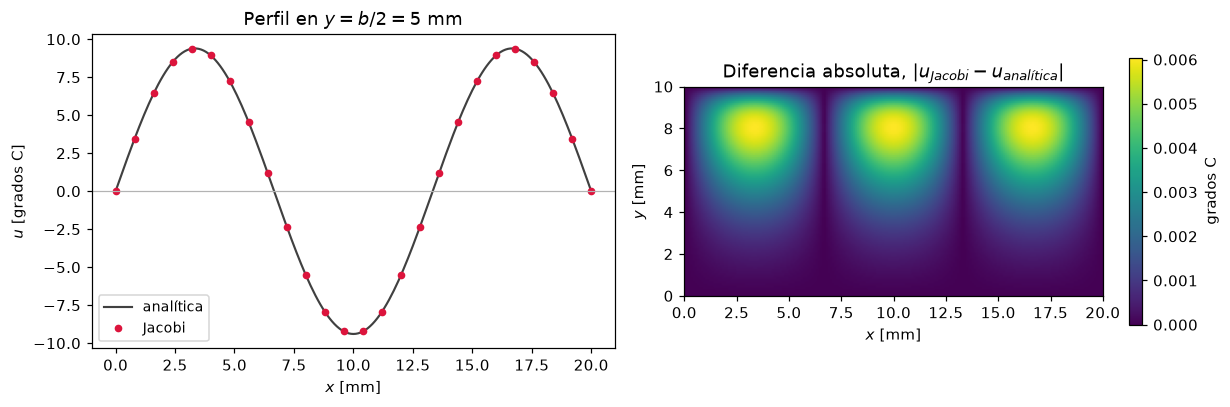

In [5]:
j_medio = ny//2
salto = 8

fig, (ax_perfil, ax_dif) = plt.subplots(1, 2, figsize=(11.4, 3.8))

ax_perfil.plot(x, u_analitica[:, j_medio], color="0.25", lw=1.4, label="analítica")
ax_perfil.plot(x[::salto], u_estatica[::salto, j_medio], "o", ms=4, color="crimson", label="Jacobi")
ax_perfil.axhline(0.0, color="0.7", lw=0.8)
ax_perfil.set_xlabel("$x$ [mm]")
ax_perfil.set_ylabel("$u$ [grados C]")
ax_perfil.set_title(f"Perfil en $y=b/2={y[j_medio]:.0f}$ mm")
ax_perfil.legend(fontsize=9)

imagen_dif = ax_dif.imshow(diferencia.T, origin="lower", extent=[0.0, a, 0.0, b],
                           cmap="viridis", aspect="equal")
ax_dif.set_xlabel("$x$ [mm]")
ax_dif.set_ylabel("$y$ [mm]")
ax_dif.set_title(r"Diferencia absoluta, $|u_{Jacobi}-u_{analítica}|$")
fig.colorbar(imagen_dif, ax=ax_dif, label="grados C", shrink=0.85)

fig.tight_layout()
plt.show()

Sobre el perfil las dos soluciones se confunden, la diferencia es demasiado pequeña para el ojo
frente a los $100$ grados C de escala. El mapa de la derecha la hace visible: crece pegada al
borde caliente, donde la curvatura del $\mathrm{senh}$ es mayor y la molécula de cinco puntos, que
es de orden $\Delta^2$, pierde más precisión, y cae a casi cero hacia el borde frío de abajo.

---

# 3. Difusión en el tiempo

Con la derivada temporal hacia adelante y las espaciales centradas, la ecuación de difusión da el
valor del nodo en el nivel $n+1$ a partir del nivel $n$:

$$u^{n+1}_{i,j}=u^{n}_{i,j}+D\,\Delta t\left(
\frac{u^{n}_{i+1,j}-2u^{n}_{i,j}+u^{n}_{i-1,j}}{\Delta x^{2}}
+\frac{u^{n}_{i,j+1}-2u^{n}_{i,j}+u^{n}_{i,j-1}}{\Delta y^{2}}\right).$$

El esquema es explícito, así que el paso de tiempo no es libre: el cuaderno de difusión del curso
usa el mayor permitido,

$$\Delta t=\frac{\Delta x^{2}\Delta y^{2}}{2D(\Delta x^{2}+\Delta y^{2})},$$

que con $\Delta x=\Delta y=0.1$ mm y $D=84\ \text{mm}^2/\text{s}$ vale $2.98\times10^{-5}$ s. La
placa arranca a $0$ C en el interior y el borde superior queda en $f(x)$ desde $t=0$.

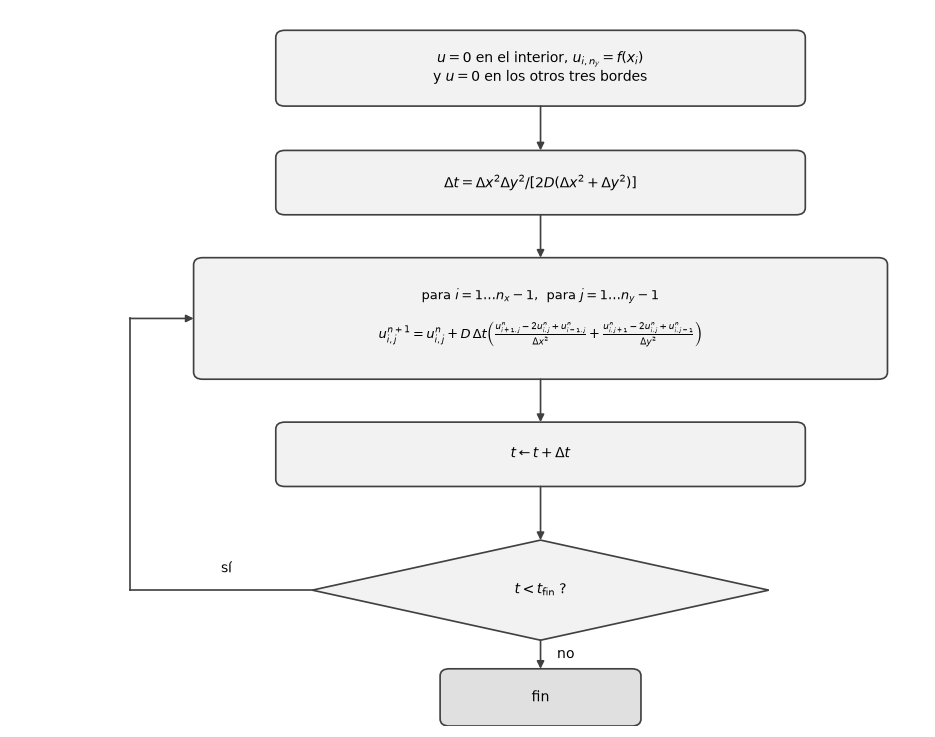

In [6]:
def paso_explicito(u_viejo, dt):
    """Un paso del esquema explicito."""
    u = u_viejo.copy()
    uxx = (u_viejo[2:, 1:-1] - 2.0*u_viejo[1:-1, 1:-1] + u_viejo[:-2, 1:-1])/(dx*dx)
    uyy = (u_viejo[1:-1, 2:] - 2.0*u_viejo[1:-1, 1:-1] + u_viejo[1:-1, :-2])/(dy*dy)
    u[1:-1, 1:-1] = u_viejo[1:-1, 1:-1] + dt*D*(uxx + uyy)
    return u


def evolucion(dt, referencia, tolerancia, cada, max_pasos=1000000):
    """Avanza hasta pegarse a la referencia."""
    u = malla_inicial()
    guardadas = [(0.0, u.copy())]
    t = 0.0
    for pasos in range(1, max_pasos+1):
        u = paso_explicito(u, dt)
        t += dt
        distancia = np.abs(u - referencia).max()
        llego = distancia < tolerancia
        if pasos % cada == 0 or llego:
            guardadas.append((t, u.copy()))
        if llego:
            return u, pasos, t, distancia, guardadas
    return u, max_pasos, t, distancia, guardadas


dt = dx*dx*dy*dy/(2.0*D*(dx*dx + dy*dy))

reloj = time.perf_counter()
u_final, pasos, t_final, distancia, guardadas = evolucion(dt, u_estatica, 0.05, cada=200)

print(f"dt = {dt:.3e} s")
print(f"{pasos} pasos en {time.perf_counter() - reloj:.2f} s de reloj")
print(f"tiempo fisico: {t_final:.4f} s")
print(f"diferencia con la solucion estatica: {distancia:.4f} grados C")

dt = 2.976e-05 s
7414 pasos en 0.87 s de reloj
tiempo fisico: 0.2207 s
diferencia con la solucion estatica: 0.0500 grados C


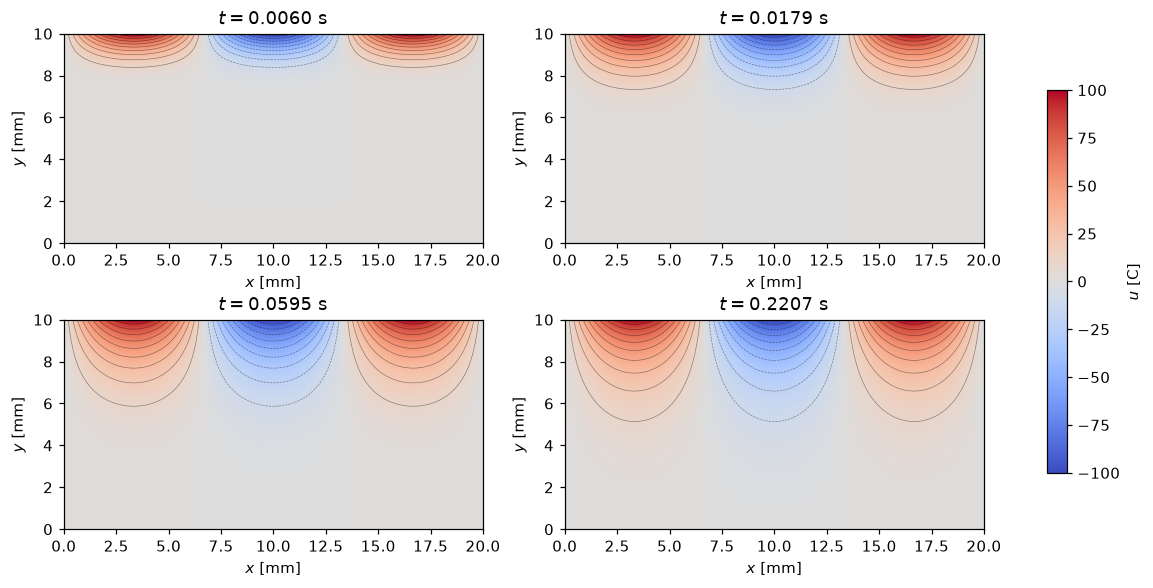

In [7]:
objetivos = [0.0060, 0.0179, 0.0595, t_final]
elegidas = []
for objetivo in objetivos:
    mejor = 0
    for indice in range(len(guardadas)):
        if abs(guardadas[indice][0] - objetivo) < abs(guardadas[mejor][0] - objetivo):
            mejor = indice
    elegidas.append(guardadas[mejor])

sin_cero = [nivel for nivel in np.linspace(-90.0, 90.0, 19) if abs(nivel) > 1.0]

fig, ejes = plt.subplots(2, 2, figsize=(10.4, 5.2), constrained_layout=True)
for ax, (instante, campo) in zip(ejes.ravel(), elegidas):
    imagen = mapa_temperatura(ax, campo, f"$t={instante:.4f}$ s", niveles=sin_cero)
fig.colorbar(imagen, ax=ejes.ravel().tolist(), label="$u$ [C]", shrink=0.75)
plt.show()

El calor entra por el borde superior y avanza hacia abajo como un frente: a $t=0.0060$ s solo se
ha movido un par de milímetros, a $t=0.0179$ s los tres lóbulos ya están formados y a $t=0.0595$ s
el perfil casi no cambia. Tras $7414$ pasos, $t=0.2207$ s, la diferencia máxima con el campo
relajado del punto 1 baja de $0.05$ C: el transitorio termina en la misma solución estacionaria,
calculada esta vez sin relajar.

---

# 4. Animación de la temperatura

Los campos guardados durante la evolución, uno cada $200$ pasos, se recorren con `FuncAnimation` y
se escriben como GIF.

39 cuadros, de t = 0 a t = 0.2207 s


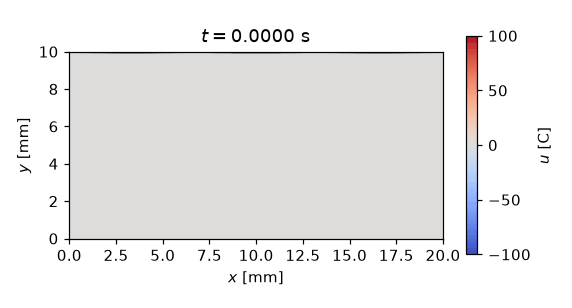

In [8]:
fig_gif, ax_gif = plt.subplots(figsize=(5.2, 2.8))
imagen_gif = ax_gif.imshow(guardadas[0][1].T, origin="lower", extent=[0.0, a, 0.0, b],
                           cmap="coolwarm", vmin=-100.0, vmax=100.0, aspect="equal")
ax_gif.set_xlabel("$x$ [mm]")
ax_gif.set_ylabel("$y$ [mm]")
titulo_gif = ax_gif.set_title("")
fig_gif.colorbar(imagen_gif, ax=ax_gif, label="$u$ [C]", shrink=0.85)
fig_gif.tight_layout()


def dibujar_cuadro(indice):
    """Campo guardado en `indice`."""
    instante, campo = guardadas[indice]
    imagen_gif.set_data(campo.T)
    titulo_gif.set_text(f"$t={instante:.4f}$ s")
    return imagen_gif, titulo_gif


anima = animation.FuncAnimation(fig_gif, dibujar_cuadro, frames=len(guardadas), blit=False)
anima.save("difusion.gif", writer=animation.PillowWriter(fps=10))
plt.close(fig_gif)

print(f"{len(guardadas)} cuadros, de t = 0 a t = {guardadas[-1][0]:.4f} s")
Image("difusion.gif")

---

## Referencias

- R. Landau, M. J. Páez y C. Bordeianu, *Computational Physics*, 3.ª ed., Wiley-VCH (2015),
  capítulo de flujo de calor por pasos de tiempo, de donde sale la condición de estabilidad del
  esquema explícito.
- Material del curso: `Sesiones/PDE/1_PDE_theory.ipynb` para la separación de variables con
  $\mathrm{senh}$, y `Sesiones/PDE/2.2_FDM_diffusion.ipynb` para el esquema explícito y el paso de
  tiempo máximo.